Carregar e Filtar

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_parquet("../data/processed/escolas_limpo.parquet")

al = df[df["CO_UF"] == 27].copy()
print(f"Alagoas: {al.shape[0]:,} escolas")
print(f"Municípios: {al['NO_MUNICIPIO'].nunique()}")
al.head(3)

Alagoas: 3,473 escolas
Municípios: 102


,NO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,TP_DEPENDENCIA,TP_LOCALIZACAO,IN_BANHEIRO_PNE,IN_BIBLIOTECA,...,QT_MAT_BAS_BRANCA,QT_MAT_BAS_PRETA,QT_MAT_BAS_PARDA,QT_MAT_BAS_AMARELA,QT_MAT_BAS_INDIGENA,QT_DOC_BAS,REDE,LOCALIZACAO,RACA_PREDOMINANTE,PERC_NEGROS
76195,Nordeste,Alagoas,AL,27,Água Branca,2700102,2,1,1.0,1.0,...,19.0,2.0,348.0,1.0,0.0,29.0,Estadual,Urbana,Parda,85.574572
76196,Nordeste,Alagoas,AL,27,Água Branca,2700102,3,1,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,NaN,Municipal,Urbana,Branca,NaN
76197,Nordeste,Alagoas,AL,27,Água Branca,2700102,3,1,0.0,0.0,...,9.0,0.0,100.0,0.0,0.0,14.0,Municipal,Urbana,Parda,29.673591


Panorama geral de Alagoas

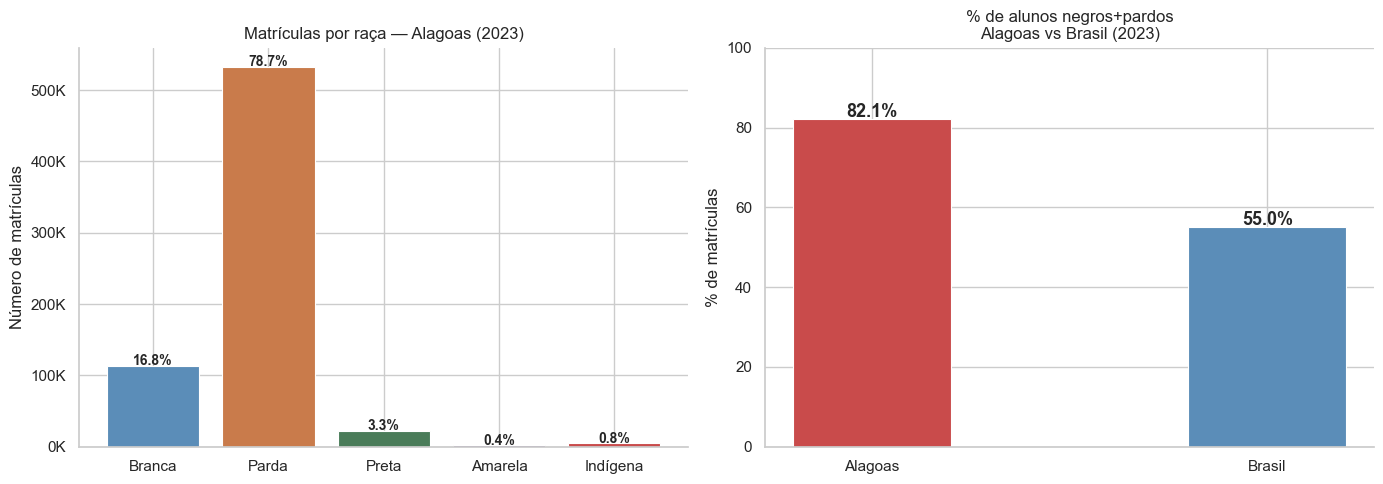

In [5]:
# matrículas por raça em Alagoas
racas_al = {
    "Branca":   al["QT_MAT_BAS_BRANCA"].sum(),
    "Parda":    al["QT_MAT_BAS_PARDA"].sum(),
    "Preta":    al["QT_MAT_BAS_PRETA"].sum(),
    "Amarela":  al["QT_MAT_BAS_AMARELA"].sum(),
    "Indígena": al["QT_MAT_BAS_INDIGENA"].sum(),
}
total_al = sum(racas_al.values())

cores = ["#5B8DB8", "#C97B4B", "#4A7C59", "#8B6B9E", "#C94B4B"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(racas_al.keys(), racas_al.values(), color=cores,
                   edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, racas_al.values()):
    pct = val / total_al * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{pct:.1f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Matrículas por raça — Alagoas (2023)", fontsize=12)
axes[0].set_ylabel("Número de matrículas")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

negros_al   = (racas_al["Preta"] + racas_al["Parda"]) / total_al * 100
negros_br   = (df["QT_MAT_BAS_PRETA"].sum() + df["QT_MAT_BAS_PARDA"].sum()) / \
               (df["QT_MAT_BAS_BRANCA"].sum() + df["QT_MAT_BAS_PARDA"].sum() +
                df["QT_MAT_BAS_PRETA"].sum() + df["QT_MAT_BAS_AMARELA"].sum() +
                df["QT_MAT_BAS_INDIGENA"].sum()) * 100

axes[1].bar(["Alagoas", "Brasil"], [negros_al, negros_br],
            color=["#C94B4B", "#5B8DB8"], edgecolor="white", linewidth=0.8, width=0.4)
for i, val in enumerate([negros_al, negros_br]):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=13, fontweight="bold")
axes[1].set_title("% de alunos negros+pardos\nAlagoas vs Brasil (2023)", fontsize=12)
axes[1].set_ylabel("% de matrículas")
axes[1].set_ylim(0, 100)

sns.despine()
plt.tight_layout()
plt.savefig("../outputs/05_panorama_alagoas.png", dpi=150)
plt.show()

Infraestrutura

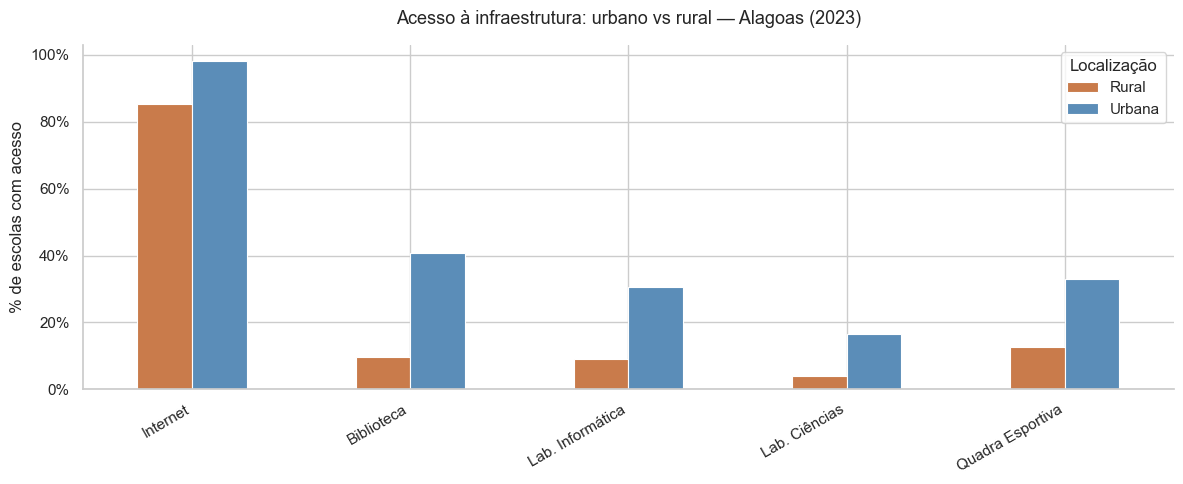

In [6]:
infra_cols = {
    "IN_INTERNET":               "Internet",
    "IN_BIBLIOTECA":             "Biblioteca",
    "IN_LABORATORIO_INFORMATICA":"Lab. Informática",
    "IN_LABORATORIO_CIENCIAS":   "Lab. Ciências",
    "IN_QUADRA_ESPORTES":        "Quadra Esportiva",
}

for col in infra_cols:
    al[col] = pd.to_numeric(al[col], errors="coerce")

infra_al = (
    al.groupby("LOCALIZACAO")[list(infra_cols.keys())]
    .mean() * 100
).rename(columns=infra_cols)

fig, ax = plt.subplots(figsize=(12, 5))
infra_al.T.plot(kind="bar", ax=ax, color=["#C97B4B", "#5B8DB8"],
                edgecolor="white", linewidth=0.8)
ax.set_title("Acesso à infraestrutura: urbano vs rural — Alagoas (2023)", fontsize=13, pad=15)
ax.set_ylabel("% de escolas com acesso")
ax.set_xlabel("")
ax.legend(title="Localização")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/06_infraestrutura_al_urbano_rural.png", dpi=150)
plt.show()